<a href="https://colab.research.google.com/github/ArpitaRPatki/NLP-LAB/blob/main/NLP_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Cell 1: Install and import
!pip install spacy
!python -m spacy download en_core_web_sm

import spacy
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


✅ All libraries imported successfully!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [9]:
# Cell 2: Input paragraph
paragraph = """
Artificial intelligence is transforming the modern world in remarkable ways.
Machine learning algorithms help doctors detect serious diseases at an early stage.
Deep learning models are used by large technology companies to build smart applications.
Natural language processing enables intelligent chatbots to understand human emotions.
Computer vision systems allow self-driving cars to navigate busy city roads safely.
Data scientists use powerful programming languages like Python to analyze huge datasets.
Cloud computing platforms provide flexible storage solutions for global businesses.
Neural networks have revolutionized image recognition and speech processing tasks.
Robotics engineers design advanced mechanical systems for manufacturing industries.
Big data analytics tools help business managers make better financial decisions.
"""

print("✅ Paragraph loaded!")
print(f"Total words      : {len(paragraph.split())}")
print(f"Total sentences  : {paragraph.strip().count(chr(10))}")
print(f"\nParagraph Preview:\n{paragraph[:200]}...")

✅ Paragraph loaded!
Total words      : 109
Total sentences  : 9

Paragraph Preview:

Artificial intelligence is transforming the modern world in remarkable ways.
Machine learning algorithms help doctors detect serious diseases at an early stage.
Deep learning models are used by large...


In [10]:
# Cell 3: Tokenize and POS tag using NLTK
from nltk import word_tokenize, pos_tag

tokens   = word_tokenize(paragraph)
pos_tags = pos_tag(tokens)

print("✅ Tokenization & POS Tagging done!")
print(f"\nTotal tokens: {len(tokens)}")
print(f"\n{'Token':<25} {'POS Tag':<12} {'Meaning'}")
print("-" * 55)

tag_meaning = {
    'NN':'Singular Noun', 'NNS':'Plural Noun',
    'NNP':'Proper Noun',  'NNPS':'Plural Proper Noun',
    'JJ':'Adjective',     'DT':'Determiner',
    'VB':'Verb',          'RB':'Adverb'
}

count = 0
for word, tag in pos_tags:
    if tag in tag_meaning and word.isalpha():
        print(f"{word:<25} {tag:<12} {tag_meaning.get(tag,'')}")
        count += 1
        if count == 15:
            break

✅ Tokenization & POS Tagging done!

Total tokens: 119

Token                     POS Tag      Meaning
-------------------------------------------------------
Artificial                JJ           Adjective
intelligence              NN           Singular Noun
the                       DT           Determiner
modern                    JJ           Adjective
world                     NN           Singular Noun
remarkable                JJ           Adjective
ways                      NNS          Plural Noun
Machine                   NNP          Proper Noun
algorithms                JJ           Adjective
help                      NN           Singular Noun
doctors                   NNS          Plural Noun
serious                   JJ           Adjective
diseases                  NNS          Plural Noun
an                        DT           Determiner
early                     JJ           Adjective


In [11]:
# Cell 4: Define grammar and extract noun phrases using NLTK RegexpParser
import nltk

# Grammar Rule: Noun Phrase = optional DET + optional ADJ + one or more NOUNS
grammar = r"""
    NP: {<DT>?<JJ>*<NN.*>+}
"""

parser = nltk.RegexpParser(grammar)
tree   = parser.parse(pos_tags)

# Extract all NP chunks
nltk_noun_phrases = []
for subtree in tree.subtrees():
    if subtree.label() == 'NP':
        phrase = ' '.join(word for word, tag in subtree.leaves())
        nltk_noun_phrases.append(phrase)

nltk_noun_phrases = list(set(nltk_noun_phrases))

print("✅ NLTK Noun Phrases extracted!")
print(f"Total found: {len(nltk_noun_phrases)}")
print("\nAll Noun Phrases:")
for i, phrase in enumerate(nltk_noun_phrases, 1):
    print(f"  {i:2}. {phrase}")

✅ NLTK Noun Phrases extracted!
Total found: 33

All Noun Phrases:
   1. image recognition
   2. the modern world
   3. powerful programming languages
   4. Robotics engineers design
   5. global businesses
   6. Deep learning models
   7. remarkable ways
   8. serious diseases
   9. Machine
  10. huge datasets
  11. Data scientists
  12. Artificial intelligence
  13. intelligent chatbots
  14. financial decisions
  15. an early stage
  16. Cloud
  17. Big data analytics
  18. algorithms help doctors
  19. busy city roads
  20. speech processing tasks
  21. platforms
  22. Neural networks
  23. help business managers
  24. Natural language processing
  25. industries
  26. large technology companies
  27. smart applications
  28. flexible storage solutions
  29. Computer vision systems
  30. self-driving cars
  31. mechanical systems
  32. Python
  33. human emotions


In [12]:
# Cell 5: Extract noun phrases using spaCy noun_chunks
nlp = spacy.load("en_core_web_sm")
doc = nlp(paragraph)

spacy_noun_phrases = []
for chunk in doc.noun_chunks:
    spacy_noun_phrases.append({
        'Noun Phrase' : chunk.text.strip(),
        'Root Word'   : chunk.root.text,
        'POS Tag'     : chunk.root.pos_,
        'Word Count'  : len(chunk.text.split())
    })

df_spacy = pd.DataFrame(spacy_noun_phrases).drop_duplicates(subset='Noun Phrase')
df_spacy = df_spacy.reset_index(drop=True)
df_spacy.index += 1

print("✅ spaCy Noun Phrases extracted!")
print(f"Total found: {len(df_spacy)}\n")
print(df_spacy.to_string())

✅ spaCy Noun Phrases extracted!
Total found: 32

                       Noun Phrase     Root Word POS Tag  Word Count
1          Artificial intelligence  intelligence    NOUN           2
2                 the modern world         world    NOUN           3
3                  remarkable ways          ways    NOUN           2
4      Machine learning algorithms    algorithms    NOUN           3
5                          doctors       doctors    NOUN           1
6                 serious diseases      diseases    NOUN           2
7                   an early stage         stage    NOUN           3
8             Deep learning models        models    NOUN           3
9       large technology companies     companies    NOUN           3
10              smart applications  applications    NOUN           2
11     Natural language processing    processing    NOUN           3
12            intelligent chatbots      chatbots    NOUN           2
13                  human emotions      emotions    NO

In [13]:
# Cell 6: Compare both methods
print("=" * 55)
print("      NLTK  vs  spaCy  COMPARISON")
print("=" * 55)
print(f"  NLTK  (RegexpParser) : {len(nltk_noun_phrases):>3} noun phrases")
print(f"  spaCy (noun_chunks)  : {len(df_spacy):>3} noun phrases")
print("=" * 55)

# Common phrases in both
spacy_set = set(df_spacy['Noun Phrase'].str.lower())
nltk_set  = set([p.lower() for p in nltk_noun_phrases])
common    = spacy_set & nltk_set

print(f"\n  Common phrases found in BOTH: {len(common)}")
for p in list(common)[:5]:
    print(f"    → {p}")

      NLTK  vs  spaCy  COMPARISON
  NLTK  (RegexpParser) :  33 noun phrases
  spaCy (noun_chunks)  :  32 noun phrases

  Common phrases found in BOTH: 23
    → image recognition
    → the modern world
    → powerful programming languages
    → deep learning models
    → global businesses


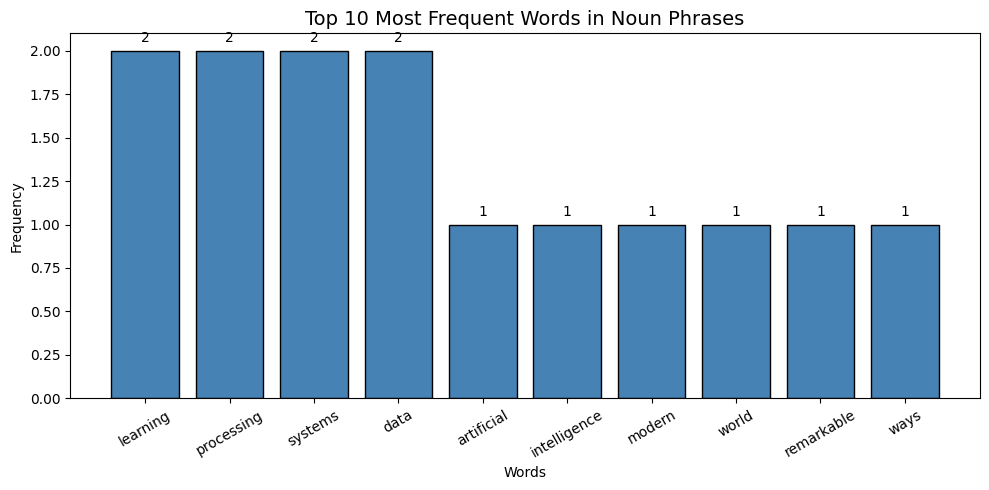

✅ Bar chart displayed!


In [14]:
# Cell 7: Plot top noun phrases by word count
from collections import Counter

all_words_in_phrases = []
for phrase in df_spacy['Noun Phrase']:
    all_words_in_phrases.extend(phrase.lower().split())

# Remove stop words manually
stopwords = {'the','a','an','this','that','these','those','its','their','our'}
filtered  = [w for w in all_words_in_phrases if w not in stopwords and len(w) > 2]
freq      = Counter(filtered).most_common(10)

words, counts = zip(*freq)

plt.figure(figsize=(10, 5))
bars = plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 10 Most Frequent Words in Noun Phrases', fontsize=14)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=30)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print("✅ Bar chart displayed!")

In [15]:


doc = nlp(paragraph)

final = []
seen  = set()

for chunk in doc.noun_chunks:
    phrase = chunk.text.strip()
    if phrase.lower() not in seen and len(phrase) > 2:
        seen.add(phrase.lower())
        final.append({
            'Noun Phrase'  : phrase,
            'Root Word'    : chunk.root.text,
            'POS Tag'      : chunk.root.pos_,
            'Words'        : len(phrase.split()),
            'NP Type'      : 'Proper' if chunk.root.pos_=='PROPN' else 'Common'
        })

final_df = pd.DataFrame(final[:15])
final_df.index = range(1, len(final_df)+1)
final_df.index.name = 'No.'

print("=" * 72)
print("      NLP — NOUN PHRASE EXTRACTION RESULTS (15 OUTPUTS)")
print("=" * 72)
print(final_df.to_string())
print("=" * 72)
print(f"\n  Technique : spaCy NP Chunking  +  NLTK RegexpParser")
print(f"  Model     : en_core_web_sm (spaCy CNN model)")
print(f"  Grammar   : DT(optional) + JJ(optional) + NN(one or more)")
print(f"  Total NPs : {len(final_df)}")
print(f"  Paragraph : {len(paragraph.split())} words")
print("=" * 72)

      NLP — NOUN PHRASE EXTRACTION RESULTS (15 OUTPUTS)
                     Noun Phrase     Root Word POS Tag  Words NP Type
No.                                                                  
1        Artificial intelligence  intelligence    NOUN      2  Common
2               the modern world         world    NOUN      3  Common
3                remarkable ways          ways    NOUN      2  Common
4    Machine learning algorithms    algorithms    NOUN      3  Common
5                        doctors       doctors    NOUN      1  Common
6               serious diseases      diseases    NOUN      2  Common
7                 an early stage         stage    NOUN      3  Common
8           Deep learning models        models    NOUN      3  Common
9     large technology companies     companies    NOUN      3  Common
10            smart applications  applications    NOUN      2  Common
11   Natural language processing    processing    NOUN      3  Common
12          intelligent chatbots  